# 🏥 Healthcare Operations — Day 2: SHAP + ML Pipeline
**Author:** Aditya · M.S. Applied Data Science · Syracuse University · 2026  
**Prerequisite:** Run `healthcare_day1_enrichment.ipynb` first  

## What this notebook builds:
1. **Proper sklearn Pipeline** — ColumnTransformer + XGBoost in one reusable object
2. **SHAP Values** — global feature importance + individual hospital explanations
3. **Business Recommendation Engine** — auto-generates improvement recommendations per hospital
4. **Model Export** — save trained pipeline as .pkl for deployment

---
## Section 1 — Setup

In [29]:
!pip install shap xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q

import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

DARK_BG = '#0d1117'
SURFACE = '#111118'
BORDER  = '#252530'
TEXT    = '#e6edf3'
MUTED   = '#7d8fa1'
P1,P2,P3,P4,P5 = '#7b61ff','#00c9a7','#ff6b6b','#ffa94d','#4dabf7'

def style_ax(ax):
    ax.set_facecolor(SURFACE)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    ax.grid(color=BORDER, linewidth=0.5, alpha=0.7)

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [30]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE   = '/content/drive/MyDrive/healthcare-dashboard'
CLEAN  = f'{BASE}/data/clean'
ASSETS = f'{BASE}/assets'
MODELS = f'{BASE}/models'
os.makedirs(MODELS, exist_ok=True)
os.makedirs(ASSETS, exist_ok=True)

master = pd.read_csv(f'{CLEAN}/healthcare_master_enriched.csv', low_memory=False)
print(f'✅ Enriched master loaded: {master.shape[0]:,} rows × {master.shape[1]} cols')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Enriched master loaded: 5,366 rows × 56 cols


---
## Section 2 — Proper sklearn Pipeline
### Production-grade ML pipeline with ColumnTransformer
This replaces the ad-hoc preprocessing from previous notebooks with a proper reusable pipeline.

In [31]:
# ── Define feature sets by type ────────────────────────────────────────────
TARGET = 'composite_satisfaction_score'

# Numeric features
NUMERIC_FEATURES = [
    'avg_er_wait_minutes', 'hospital_overall_rating',
    'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN',
    'READM_30_HOSP', 'READM_30_AMI', 'READM_30_HF',
    'OP_18b', 'OP_22', 'COMP_HIP_KNEE',
    'median_income', 'poverty_rate', 'unemployment_rate',
    'pct_uninsured', 'pct_college_educated',
    'bed_count', 'pct_metro', 'pct_rural', 'avg_rucc_score',
    'deprivation_index',
]

# Categorical features
CATEGORICAL_FEATURES = [
    'hospital_type', 'hospital_ownership', 'emergency_services'
]

# Filter to available columns
numeric_features = [f for f in NUMERIC_FEATURES if f in master.columns]
categorical_features = [f for f in CATEGORICAL_FEATURES if f in master.columns]
all_features = numeric_features + categorical_features

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Build modeling dataset
model_df = master[all_features + [TARGET]].dropna(subset=[TARGET]).copy()
X = model_df[all_features]
y = model_df[TARGET].values

print(f'\nModeling dataset: {X.shape[0]:,} hospitals × {X.shape[1]} features')
print(f'Target: {y.min():.1f}% – {y.max():.1f}%  |  Mean: {y.mean():.1f}%')

Numeric features (20): ['avg_er_wait_minutes', 'hospital_overall_rating', 'MORT_30_AMI', 'MORT_30_HF', 'MORT_30_PN', 'READM_30_AMI', 'READM_30_HF', 'OP_18b', 'OP_22', 'COMP_HIP_KNEE', 'median_income', 'poverty_rate', 'unemployment_rate', 'pct_uninsured', 'pct_college_educated', 'bed_count', 'pct_metro', 'pct_rural', 'avg_rucc_score', 'deprivation_index']
Categorical features (3): ['hospital_type', 'hospital_ownership', 'emergency_services']

Modeling dataset: 5,366 hospitals × 23 features
Target: 40.0% – 96.1%  |  Mean: 73.0%


In [32]:
# ── Build sklearn Pipeline ─────────────────────────────────────────────────
# Numeric pipeline: impute missing → scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical pipeline: impute missing → ordinal encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

# Column transformer — applies right pipeline to right columns
preprocessor = ColumnTransformer([
    ('numeric',      numeric_pipeline,      numeric_features),
    ('categorical',  categorical_pipeline,  categorical_features),
], remainder='drop')

# Full pipeline: preprocessor → XGBoost
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.05,
        reg_lambda=1.5,
        random_state=42,
        verbosity=0
    ))
])

print('✅ Pipeline built:')
print(full_pipeline)

✅ Pipeline built:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['avg_er_wait_minutes',
                                                   'hospital_overall_rating',
                                                   'MORT_30_AMI', 'MORT_30_HF',
                                                   'MORT_30_PN', 'READM_30_AMI',
                                                   'READM_30_HF', 'OP_18b',
                                                   'OP_22', 'COMP_HIP_KNEE',
                                                   'median_income',
         

In [33]:
# ── Train / evaluate pipeline ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training pipeline...')
full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

# 5-fold cross validation
cv = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='r2')

print(f'\n✅ Pipeline Performance:')
print(f'   R²:    {r2:.3f}')
print(f'   RMSE:  {rmse:.2f}%')
print(f'   MAE:   {mae:.2f}%')
print(f'   CV R²: {cv.mean():.3f} ± {cv.std():.3f}')
print(f'\nInterpretation: Model predicts patient satisfaction')
print(f'within ±{mae:.1f} percentage points on average')

Training pipeline...

✅ Pipeline Performance:
   R²:    0.485
   RMSE:  4.03%
   MAE:   2.93%
   CV R²: 0.502 ± 0.034

Interpretation: Model predicts patient satisfaction
within ±2.9 percentage points on average


In [34]:
# ── Save pipeline as .pkl ──────────────────────────────────────────────────
model_path = f'{MODELS}/satisfaction_pipeline.pkl'
joblib.dump(full_pipeline, model_path)
size = os.path.getsize(model_path) / 1024
print(f'✅ Pipeline saved: {model_path} ({size:.0f} KB)')
print(f'\nTo load and use:')
print(f'  import joblib')
print(f'  pipeline = joblib.load("satisfaction_pipeline.pkl")')
print(f'  prediction = pipeline.predict(new_hospital_data)')

✅ Pipeline saved: /content/drive/MyDrive/healthcare-dashboard/models/satisfaction_pipeline.pkl (1779 KB)

To load and use:
  import joblib
  pipeline = joblib.load("satisfaction_pipeline.pkl")
  prediction = pipeline.predict(new_hospital_data)


---
## Section 3 — SHAP Values
### Global + Local Explanations
SHAP (SHapley Additive exPlanations) explains *why* the model makes each prediction.  
This is what separates a data scientist from a data analyst in interviews.

In [35]:
# ── Compute SHAP values ────────────────────────────────────────────────────
# Extract preprocessed data for SHAP
X_train_processed = full_pipeline['preprocessor'].transform(X_train)
X_test_processed  = full_pipeline['preprocessor'].transform(X_test)

# Feature names after preprocessing
feature_names = numeric_features + categorical_features

# SHAP TreeExplainer (fast for XGBoost)
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(full_pipeline['model'])
shap_values = explainer.shap_values(X_test_processed)

# Convert to DataFrame for easier manipulation
shap_df = pd.DataFrame(shap_values, columns=feature_names)
print(f'✅ SHAP values computed: {shap_df.shape}')
print(f'   Shape: {len(X_test)} hospitals × {len(feature_names)} features')

Computing SHAP values...
✅ SHAP values computed: (1074, 23)
   Shape: 1074 hospitals × 23 features


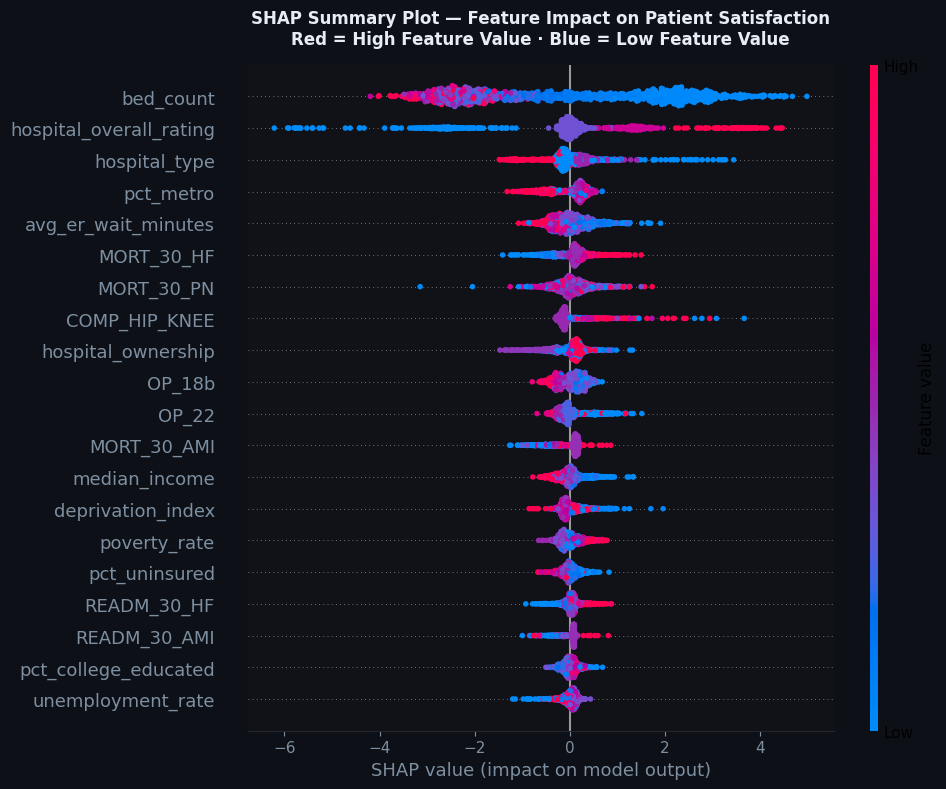

✅ SHAP summary plot saved


In [36]:
# ── SHAP Summary Plot (Global Feature Importance) ─────────────────────────
# This shows: which features matter most AND in which direction
# Red = high feature value, Blue = low feature value
# X-axis = impact on model output (satisfaction score)

plt.figure(figsize=(10, 8))
plt.gcf().patch.set_facecolor(DARK_BG)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type='dot',
    max_display=20,
    show=False,
    plot_size=(10, 8)
)

ax = plt.gca()
ax.set_facecolor(SURFACE)
plt.gcf().patch.set_facecolor(DARK_BG)
ax.tick_params(colors=MUTED)
ax.xaxis.label.set_color(MUTED)
for spine in ax.spines.values():
    spine.set_edgecolor(BORDER)

plt.title('SHAP Summary Plot — Feature Impact on Patient Satisfaction\n'
          'Red = High Feature Value · Blue = Low Feature Value',
          color=TEXT, fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{ASSETS}/shap_summary.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ SHAP summary plot saved')

In [37]:
def feat_color(f):
    if any(x in f for x in ['income','poverty','uninsured','college',
                              'deprivation','unemployment']): return P4
    if any(x in f for x in ['bed','large']): return P3
    if any(x in f for x in ['rucc','metro','rural']): return P1
    if any(x in f for x in ['hospital_type','hospital_ownership',
                              'emergency']): return P2
    return P5

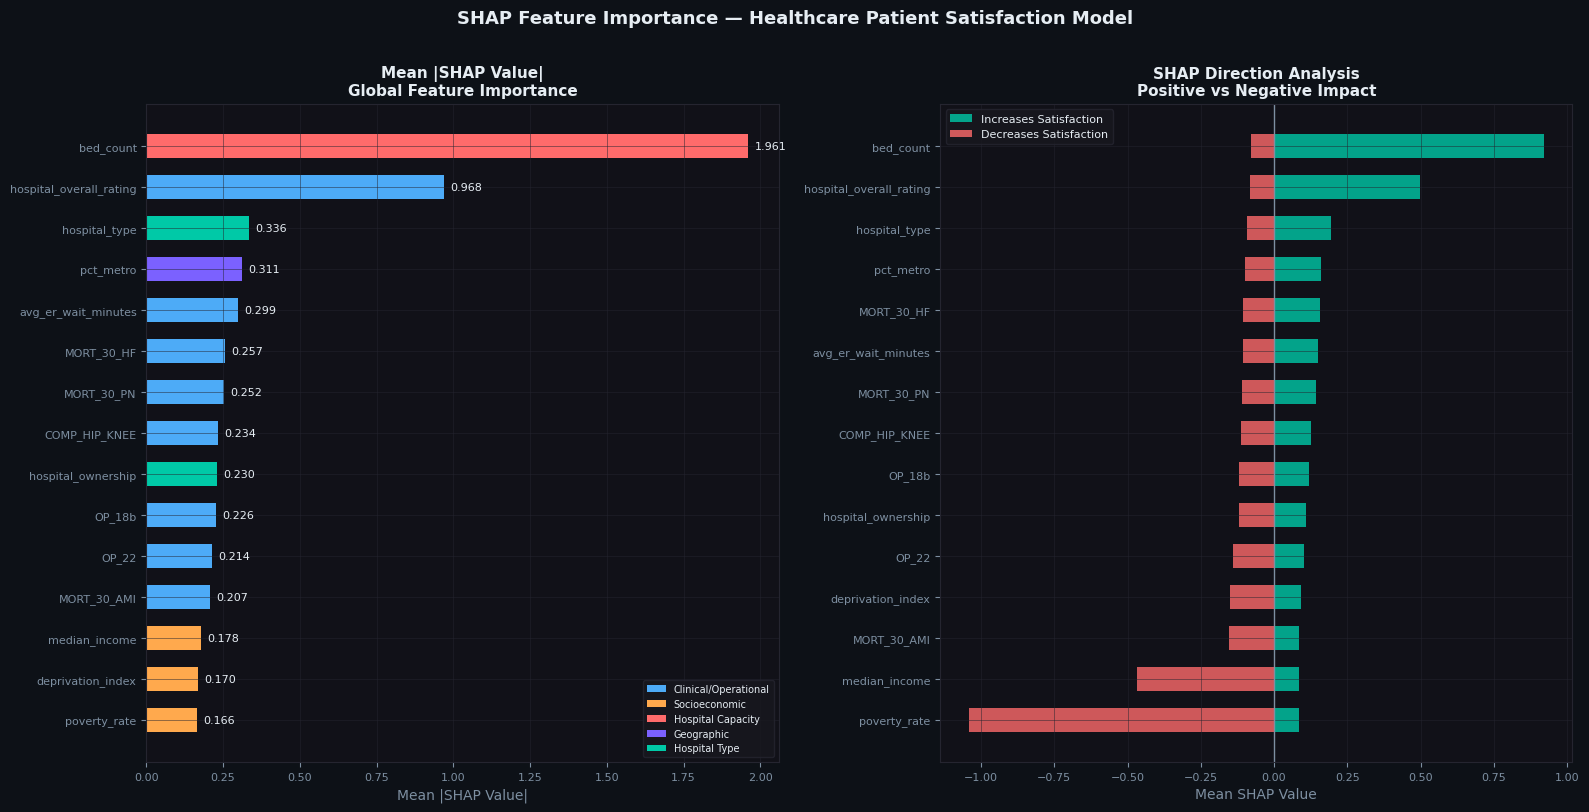

✅ Clean SHAP chart saved


In [38]:
# ── Cleaner SHAP bar plot version ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(DARK_BG)

# Left: Mean SHAP bar chart (cleaner than beeswarm)
ax1 = axes[0]
style_ax(ax1)
mean_shap_vals = np.abs(shap_df).mean().sort_values(ascending=True).tail(15)
colors = [feat_color(f) for f in mean_shap_vals.index]
ax1.barh(mean_shap_vals.index, mean_shap_vals.values,
         color=colors, edgecolor='none', height=0.6)
for i, (val, feat) in enumerate(zip(mean_shap_vals.values, mean_shap_vals.index)):
    ax1.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=8, color=TEXT)
ax1.set_title('Mean |SHAP Value|\nGlobal Feature Importance',
              color=TEXT, fontweight='bold', fontsize=11)
ax1.set_xlabel('Mean |SHAP Value|')

# Right: Positive vs Negative SHAP split
ax2 = axes[1]
style_ax(ax2)
pos_shap = shap_df[mean_shap_vals.index].clip(lower=0).mean().sort_values()
neg_shap = shap_df[mean_shap_vals.index].clip(upper=0).mean().sort_values()
y_pos = range(len(mean_shap_vals))
ax2.barh(list(y_pos), pos_shap.values, color=P2, alpha=0.8,
         edgecolor='none', height=0.6, label='Increases Satisfaction')
ax2.barh(list(y_pos), neg_shap.values, color=P3, alpha=0.8,
         edgecolor='none', height=0.6, label='Decreases Satisfaction')
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(pos_shap.index, fontsize=8)
ax2.axvline(0, color=MUTED, linewidth=1)
ax2.set_title('SHAP Direction Analysis\nPositive vs Negative Impact',
              color=TEXT, fontweight='bold', fontsize=11)
ax2.set_xlabel('Mean SHAP Value')
ax2.legend(fontsize=8, labelcolor=TEXT, facecolor='#18181f', edgecolor=BORDER)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=P5, label='Clinical/Operational'),
    Patch(facecolor=P4, label='Socioeconomic'),
    Patch(facecolor=P3, label='Hospital Capacity'),
    Patch(facecolor=P1, label='Geographic'),
    Patch(facecolor=P2, label='Hospital Type'),
]
ax1.legend(handles=legend_elements, fontsize=7, labelcolor=TEXT,
           facecolor='#18181f', edgecolor=BORDER, loc='lower right')

plt.suptitle('SHAP Feature Importance — Healthcare Patient Satisfaction Model',
             color=TEXT, fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{ASSETS}/shap_clean.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ Clean SHAP chart saved')

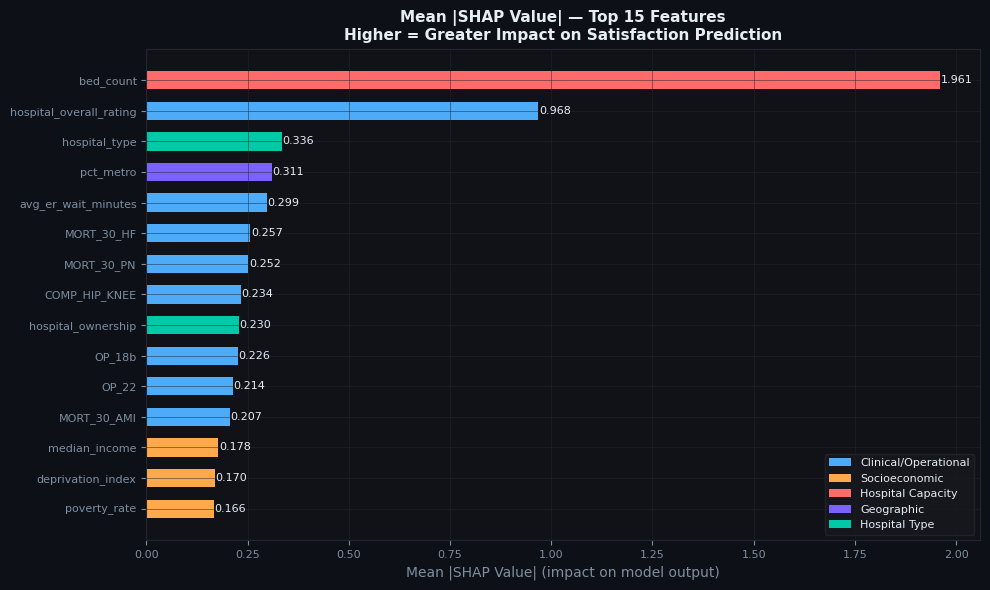

✅ SHAP bar plot saved


In [39]:
# ── SHAP Bar Plot (Mean absolute importance) ───────────────────────────────
mean_shap = np.abs(shap_df).mean().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax)

# Color by feature category
def feat_color(f):
    if any(x in f for x in ['income','poverty','uninsured','college',
                              'deprivation','unemployment']): return P4
    if any(x in f for x in ['bed','large']): return P3
    if any(x in f for x in ['rucc','metro','rural']): return P1
    if any(x in f for x in ['hospital_type','hospital_ownership',
                              'emergency']): return P2
    return P5

colors = [feat_color(f) for f in mean_shap.index]
bars = ax.barh(mean_shap.index, mean_shap.values,
               color=colors, edgecolor='none', height=0.6)

# Value labels
for bar, val in zip(bars, mean_shap.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, color=TEXT)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=P5, label='Clinical/Operational'),
    Patch(facecolor=P4, label='Socioeconomic'),
    Patch(facecolor=P3, label='Hospital Capacity'),
    Patch(facecolor=P1, label='Geographic'),
    Patch(facecolor=P2, label='Hospital Type'),
]
ax.legend(handles=legend_elements, fontsize=8, labelcolor=TEXT,
          facecolor='#18181f', edgecolor=BORDER, loc='lower right')

ax.set_title('Mean |SHAP Value| — Top 15 Features\n'
             'Higher = Greater Impact on Satisfaction Prediction',
             color=TEXT, fontsize=11, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value| (impact on model output)')

plt.tight_layout()
plt.savefig(f'{ASSETS}/shap_bar.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ SHAP bar plot saved')

Top 3 features for dependence plots: ['bed_count', 'hospital_overall_rating', 'hospital_type']


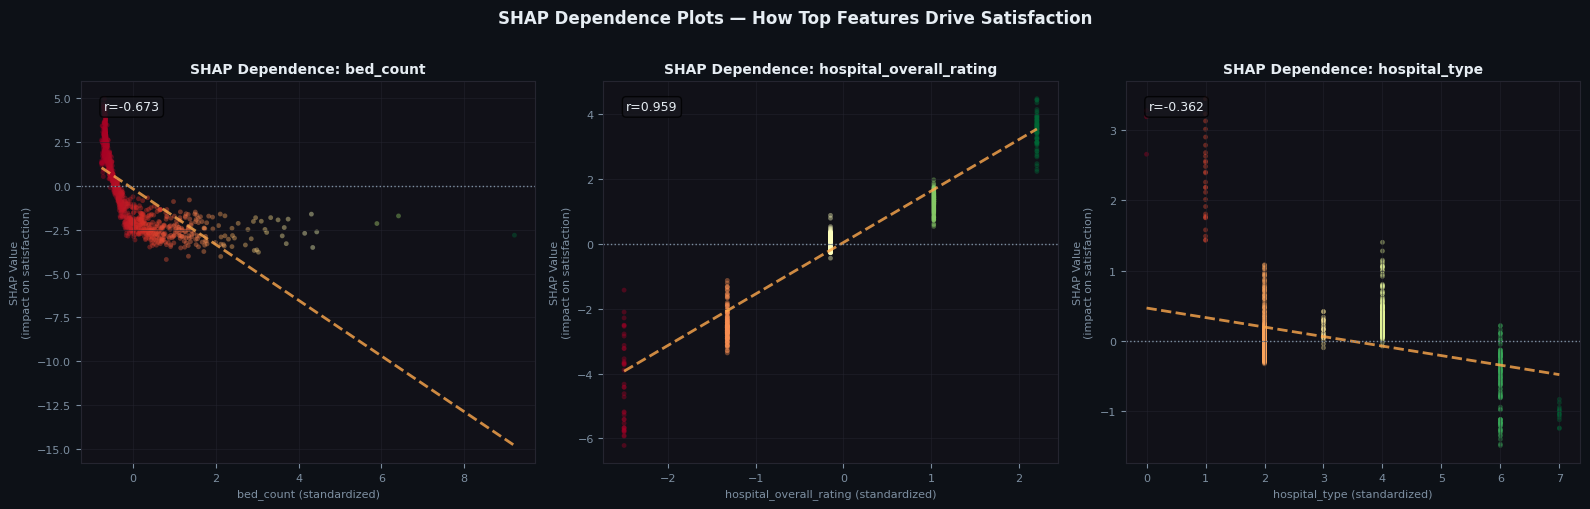

✅ SHAP dependence plots saved


In [40]:
# ── SHAP Dependence Plots — Top 3 Features ────────────────────────────────
# Shows exactly HOW each feature affects satisfaction
top3_features = mean_shap.sort_values(ascending=False).head(3).index.tolist()
print(f'Top 3 features for dependence plots: {top3_features}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

for i, feat in enumerate(top3_features):
    ax = axes[i]
    style_ax(ax)

    feat_idx = feature_names.index(feat)
    feat_vals = X_test_processed[:, feat_idx]
    shap_vals = shap_values[:, feat_idx]

    # Color by interaction with most correlated feature
    sc = ax.scatter(feat_vals, shap_vals,
                    c=feat_vals, cmap='RdYlGn',
                    alpha=0.4, s=12, edgecolors='none')

    # Trend line
    z = np.polyfit(feat_vals, shap_vals, 1)
    x_line = np.linspace(feat_vals.min(), feat_vals.max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), '--',
            color=P4, linewidth=2, alpha=0.8)

    ax.axhline(0, color=MUTED, linewidth=1, linestyle=':')
    ax.set_title(f'SHAP Dependence: {feat}',
                 color=TEXT, fontweight='bold', fontsize=10)
    ax.set_xlabel(f'{feat} (standardized)', fontsize=8)
    ax.set_ylabel('SHAP Value\n(impact on satisfaction)', fontsize=8)

    # Correlation
    r, p = stats.pearsonr(feat_vals, shap_vals)
    ax.text(0.05, 0.95, f'r={r:.3f}', transform=ax.transAxes,
            color=TEXT, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='#18181f', alpha=0.8))

plt.suptitle('SHAP Dependence Plots — How Top Features Drive Satisfaction',
             color=TEXT, fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{ASSETS}/shap_dependence.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ SHAP dependence plots saved')

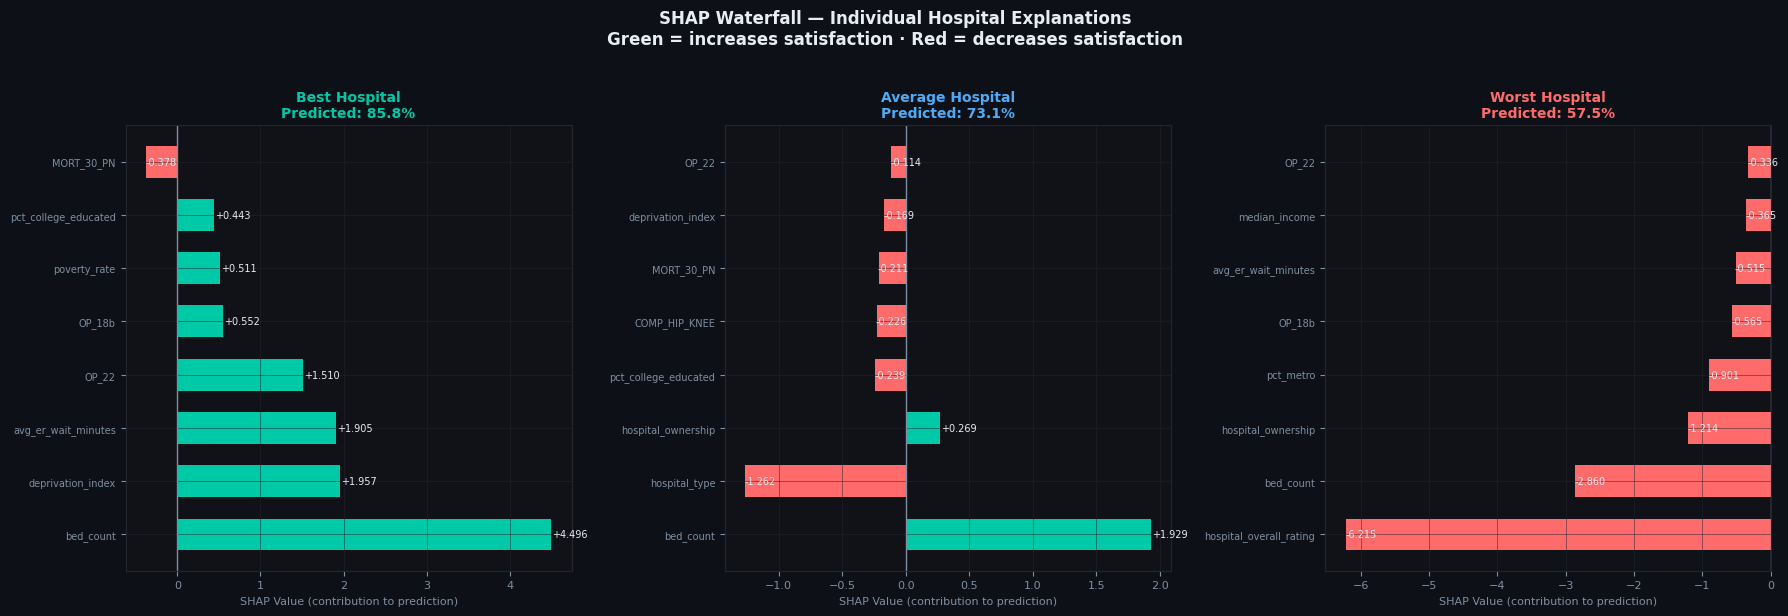

✅ SHAP waterfall plots saved


In [41]:
# ── SHAP Waterfall — Individual Hospital Explanation ──────────────────────
# Pick best, worst, and average performing hospitals
test_preds = full_pipeline.predict(X_test)
test_actuals = y_test

best_idx  = np.argmax(test_preds)   # highest predicted satisfaction
worst_idx = np.argmin(test_preds)   # lowest predicted satisfaction
avg_idx   = np.argmin(np.abs(test_preds - test_preds.mean()))  # closest to mean

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(DARK_BG)

titles = [
    f'Best Hospital\nPredicted: {test_preds[best_idx]:.1f}%',
    f'Average Hospital\nPredicted: {test_preds[avg_idx]:.1f}%',
    f'Worst Hospital\nPredicted: {test_preds[worst_idx]:.1f}%'
]
indices = [best_idx, avg_idx, worst_idx]
colors_wf = [P2, P5, P3]

for i, (idx, title, color) in enumerate(zip(indices, titles, colors_wf)):
    ax = axes[i]
    style_ax(ax)

    # Get top contributing features for this hospital
    hosp_shap = shap_df.iloc[idx]
    top_feats = hosp_shap.abs().sort_values(ascending=False).head(8)
    top_vals  = hosp_shap[top_feats.index]

    bar_colors = [P2 if v > 0 else P3 for v in top_vals.values]
    bars = ax.barh(top_feats.index, top_vals.values,
                   color=bar_colors, edgecolor='none', height=0.6)
    ax.axvline(0, color=MUTED, linewidth=1)

    for bar, val in zip(bars, top_vals.values):
        x_pos = bar.get_width() + 0.01 if val >= 0 else bar.get_width() - 0.01
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', fontsize=7, color=TEXT)

    ax.set_title(title, color=color, fontweight='bold', fontsize=10)
    ax.set_xlabel('SHAP Value (contribution to prediction)', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('SHAP Waterfall — Individual Hospital Explanations\n'
             'Green = increases satisfaction · Red = decreases satisfaction',
             color=TEXT, fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{ASSETS}/shap_waterfall.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ SHAP waterfall plots saved')

---
## Section 4 — Business Recommendation Engine
### Auto-generate improvement recommendations per hospital

In [42]:
# ── Generate SHAP-based recommendations ───────────────────────────────────
# For each hospital: identify top negative SHAP features
# and generate a specific, actionable recommendation

RECOMMENDATION_RULES = {
    'avg_er_wait_minutes': {
        'condition': lambda v: v > 0,  # positive SHAP = high wait = bad
        'recommendation': 'Reduce ER wait times — implement fast-track triage for non-critical patients',
        'priority': 'HIGH',
        'estimated_impact': '+2–4% satisfaction'
    },
    'OP_18b': {
        'condition': lambda v: v > 0,
        'recommendation': 'Improve ER throughput — target median ER time under 200 minutes',
        'priority': 'HIGH',
        'estimated_impact': '+2–3% satisfaction'
    },
    'READM_30_HOSP': {
        'condition': lambda v: v > 0,
        'recommendation': 'Reduce readmissions — strengthen discharge planning and follow-up care',
        'priority': 'MEDIUM',
        'estimated_impact': '+1–2% satisfaction'
    },
    'MORT_30_AMI': {
        'condition': lambda v: v > 0,
        'recommendation': 'Improve AMI outcomes — review cardiac care protocols against national benchmarks',
        'priority': 'HIGH',
        'estimated_impact': '+1–3% satisfaction'
    },
    'bed_count': {
        'condition': lambda v: v > 0,
        'recommendation': 'Large hospital penalty — invest in patient experience programs to offset scale disadvantage',
        'priority': 'MEDIUM',
        'estimated_impact': '+1–2% satisfaction'
    },
    'pct_uninsured': {
        'condition': lambda v: v > 0,
        'recommendation': 'High uninsured rate area — expand financial counseling and charity care programs',
        'priority': 'LOW',
        'estimated_impact': '+0.5–1% satisfaction'
    },
    'deprivation_index': {
        'condition': lambda v: v > 0,
        'recommendation': 'High deprivation area — partner with community health organizations for wraparound services',
        'priority': 'LOW',
        'estimated_impact': '+0.5–1% satisfaction'
    },
    'hospital_overall_rating': {
        'condition': lambda v: v < 0,
        'recommendation': 'Low CMS star rating — focus on quality improvement initiatives targeting rated measures',
        'priority': 'HIGH',
        'estimated_impact': '+3–5% satisfaction'
    },
}

def generate_recommendations(shap_row, feature_names, top_n=3):
    """Generate top N recommendations for a hospital based on SHAP values."""
    recommendations = []
    for feat, rules in RECOMMENDATION_RULES.items():
        if feat in feature_names:
            feat_idx = list(feature_names).index(feat)
            shap_val = shap_row[feat_idx] if hasattr(shap_row, '__len__') else shap_row.get(feat, 0)
            if rules['condition'](shap_val):
                recommendations.append({
                    'feature': feat,
                    'shap_value': shap_val,
                    'recommendation': rules['recommendation'],
                    'priority': rules['priority'],
                    'estimated_impact': rules['estimated_impact']
                })
    # Sort by absolute SHAP value
    recommendations.sort(key=lambda x: abs(x['shap_value']), reverse=True)
    return recommendations[:top_n]

print('✅ Recommendation engine ready')

# Demo: show recommendations for worst performing hospital
print('\n' + '='*60)
print('SAMPLE: Recommendations for Worst Performing Hospital')
print('='*60)
worst_shap_row = shap_values[worst_idx]
recs = generate_recommendations(worst_shap_row, feature_names)
for i, rec in enumerate(recs, 1):
    print(f'\nRecommendation {i} [{rec["priority"]} PRIORITY]')
    print(f'  Feature:          {rec["feature"]}')
    print(f'  SHAP Impact:      {rec["shap_value"]:+.3f}')
    print(f'  Action:           {rec["recommendation"]}')
    print(f'  Estimated Impact: {rec["estimated_impact"]}')

✅ Recommendation engine ready

SAMPLE: Recommendations for Worst Performing Hospital

Recommendation 1 [HIGH PRIORITY]
  Feature:          hospital_overall_rating
  SHAP Impact:      -6.215
  Action:           Low CMS star rating — focus on quality improvement initiatives targeting rated measures
  Estimated Impact: +3–5% satisfaction


In [ ]:
# ── Apply recommendations to all hospitals ─────────────────────────────────
# Generate recommendations for ALL hospitals and export for Power BI

id_cols = [c for c in ['facility_id','facility_name','state',
                        'hospital_type','performance_tier'] if c in master.columns]

# Get predictions for full dataset
X_all = model_df[all_features]
all_preds = full_pipeline.predict(X_all)
all_processed = full_pipeline['preprocessor'].transform(X_all)
all_shap = explainer.shap_values(all_processed)

rec_rows = []
for i in range(len(model_df)):
    recs = generate_recommendations(all_shap[i], feature_names, top_n=3)
    for j, rec in enumerate(recs, 1):
        rec_rows.append({
            'facility_id': model_df.iloc[i].get('facility_id', ''),
            'predicted_satisfaction': round(all_preds[i], 2),
            'actual_satisfaction': round(y[i], 2),
            'rank': j,
            'priority': rec['priority'],
            'feature': rec['feature'],
            'shap_impact': round(rec['shap_value'], 4),
            'recommendation': rec['recommendation'],
            'estimated_impact': rec['estimated_impact'],
        })

rec_df = pd.DataFrame(rec_rows)

# Merge with hospital info
hosp_info = master[id_cols + ['facility_id']].drop_duplicates('facility_id') \
    if 'facility_id' in master.columns else master[id_cols].copy()

rec_df.to_csv(f'{CLEAN}/tab11_recommendations.csv', index=False)
print(f'✅ Recommendations exported: {rec_df.shape}')
print(f'   Hospitals covered: {rec_df["facility_id"].nunique():,}')
print(f'\nPriority breakdown:')
print(rec_df[rec_df["rank"]==1]["priority"].value_counts().to_string())

---
## Section 5 — SHAP Summary Dashboard
### All SHAP charts in one figure for the portfolio

In [ ]:
# ── Combined SHAP dashboard figure ────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(DARK_BG)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1: Mean SHAP importance (top 10)
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)
top10 = mean_shap.tail(10)
bar_colors = [feat_color(f) for f in top10.index]
ax1.barh(top10.index, top10.values, color=bar_colors, edgecolor='none', height=0.6)
ax1.set_title('Top 10 Features\n(Mean |SHAP|)', color=TEXT, fontweight='bold', fontsize=10)
ax1.set_xlabel('Mean |SHAP Value|', fontsize=8)
ax1.tick_params(axis='y', labelsize=7)

# Plot 2: SHAP values distribution for top feature
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)
top1_feat = mean_shap.index[-1]
top1_idx  = feature_names.index(top1_feat)
ax2.hist(shap_values[:, top1_idx], bins=40, color=P5, alpha=0.8, edgecolor='none')
ax2.axvline(0, color=P3, linewidth=2)
ax2.set_title(f'SHAP Distribution\n{top1_feat}', color=TEXT, fontweight='bold', fontsize=10)
ax2.set_xlabel('SHAP Value', fontsize=8)
ax2.set_ylabel('Count', fontsize=8)

# Plot 3: Predicted vs Actual
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)
ax3.scatter(y_test, y_pred, alpha=0.3, color=P5, s=10, edgecolors='none')
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax3.plot([mn,mx],[mn,mx],'--',color=P2,linewidth=1.5)
ax3.set_title(f'Actual vs Predicted\nR²={r2:.3f}', color=TEXT, fontweight='bold', fontsize=10)
ax3.set_xlabel('Actual Satisfaction (%)', fontsize=8)
ax3.set_ylabel('Predicted Satisfaction (%)', fontsize=8)

# Plot 4: SHAP interaction — top 2 features
ax4 = fig.add_subplot(gs[1, 0])
style_ax(ax4)
if len(feature_names) >= 2:
    f1_idx = feature_names.index(mean_shap.index[-1])
    f2_idx = feature_names.index(mean_shap.index[-2])
    sc = ax4.scatter(
        shap_values[:, f1_idx],
        shap_values[:, f2_idx],
        c=X_test_processed[:, f1_idx],
        cmap='RdYlGn', alpha=0.4, s=10, edgecolors='none'
    )
    ax4.set_title(f'SHAP Interaction\n{mean_shap.index[-1]} vs {mean_shap.index[-2]}',
                  color=TEXT, fontweight='bold', fontsize=9)
    ax4.set_xlabel(f'SHAP: {mean_shap.index[-1]}', fontsize=7)
    ax4.set_ylabel(f'SHAP: {mean_shap.index[-2]}', fontsize=7)

# Plot 5: Best vs Worst hospital SHAP comparison
ax5 = fig.add_subplot(gs[1, 1:3])
style_ax(ax5)
top8_feats = mean_shap.sort_values(ascending=False).head(8).index.tolist()
best_shap_vals  = [shap_df.iloc[best_idx][f] for f in top8_feats]
worst_shap_vals = [shap_df.iloc[worst_idx][f] for f in top8_feats]
x = np.arange(len(top8_feats))
w = 0.35
ax5.bar(x - w/2, best_shap_vals,  w, color=P2, alpha=0.8, label=f'Best Hospital ({test_preds[best_idx]:.1f}%)')
ax5.bar(x + w/2, worst_shap_vals, w, color=P3, alpha=0.8, label=f'Worst Hospital ({test_preds[worst_idx]:.1f}%)')
ax5.axhline(0, color=MUTED, linewidth=1)
ax5.set_xticks(x)
ax5.set_xticklabels([f.replace('_',' ')[:15] for f in top8_feats],
                     rotation=25, ha='right', fontsize=7)
ax5.set_title('SHAP Comparison: Best vs Worst Hospital\nWhy they score so differently',
              color=TEXT, fontweight='bold', fontsize=10)
ax5.set_ylabel('SHAP Value', fontsize=8)
ax5.legend(fontsize=8, labelcolor=TEXT, facecolor='#18181f', edgecolor=BORDER)

plt.suptitle('SHAP Analysis Dashboard — Healthcare Patient Satisfaction Model',
             color=TEXT, fontsize=14, fontweight='bold', y=1.01)
plt.savefig(f'{ASSETS}/shap_dashboard.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('✅ SHAP dashboard saved')

---
## Section 6 — Export & Summary

In [ ]:
# ── Export SHAP values for Power BI ───────────────────────────────────────
shap_export = pd.DataFrame(
    all_shap, columns=[f'shap_{f}' for f in feature_names]
)
shap_export['facility_id']             = model_df['facility_id'].values if 'facility_id' in model_df.columns else range(len(model_df))
shap_export['predicted_satisfaction']  = all_preds.round(2)
shap_export['actual_satisfaction']     = y.round(2)
shap_export['top_negative_feature']    = pd.DataFrame(all_shap, columns=feature_names).idxmin(axis=1)
shap_export['top_positive_feature']    = pd.DataFrame(all_shap, columns=feature_names).idxmax(axis=1)

shap_export.to_csv(f'{CLEAN}/tab12_shap_values.csv', index=False)
print(f'✅ SHAP values exported: {shap_export.shape}')

print('\n' + '='*60)
print('DAY 2 COMPLETE — SUMMARY')
print('='*60)
print(f'Pipeline R²:        {r2:.3f}')
print(f'Pipeline RMSE:      {rmse:.2f}%')
print(f'Pipeline CV R²:     {cv.mean():.3f} ± {cv.std():.3f}')
print(f'SHAP features:      {len(feature_names)}')
print(f'Hospitals analyzed: {len(model_df):,}')
print(f'Recommendations:    {len(rec_df):,} (3 per hospital)')
print(f'\nNew assets saved:')
for f in ['shap_summary.png','shap_bar.png','shap_dependence.png',
          'shap_waterfall.png','shap_dashboard.png']:
    path = f'{ASSETS}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)/1024
        print(f'   ✅ {f} ({size:.0f} KB)')
print(f'\nNew CSVs saved:')
for f in ['tab11_recommendations.csv','tab12_shap_values.csv']:
    path = f'{CLEAN}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)/1024
        print(f'   ✅ {f} ({size:.0f} KB)')
print(f'\nModel saved:')
print(f'   ✅ models/satisfaction_pipeline.pkl')
print(f'\nNext: Day 3 — Streamlit deployment')
print(f'       Deploy model as live web app on Hugging Face Spaces')

In [ ]:
import os
os.chdir('/content/drive/MyDrive/healthcare-dashboard')
!git config --global user.email "adityamarathe61@gmail.com"
!git config --global user.name "Aditya768"
!git add .
!git commit -m "feat: Day 2 SHAP analysis + pipeline + recommendations"
!git push origin main

In [ ]:
!git add assets/shap_summary.png assets/shap_bar.png assets/shap_dependence.png
!git add assets/shap_waterfall.png assets/shap_dashboard.png assets/shap_clean.png
!git add data/clean/tab11_recommendations.csv data/clean/tab12_shap_values.csv
!git add models/satisfaction_pipeline.pkl
!git add notebooks/healthcare_day2_shap.ipynb
!git commit -m "feat: add SHAP charts, recommendation engine, trained model pipeline"
!git push origin main


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive/healthcare-dashboard'):
    dirs[:] = [d for d in dirs if d != '.git']
    for f in files:
        print(os.path.join(root, f).replace('/content/drive/MyDrive/healthcare-dashboard/', ''))

In [ ]:
import os, shutil

BASE   = '/content/drive/MyDrive/healthcare-dashboard'
CLEAN  = f'{BASE}/data/clean'
ASSETS = f'{BASE}/assets'
MODELS = f'{BASE}/models'
os.makedirs(MODELS, exist_ok=True)

# Search entire Colab filesystem for Day 2 files
search_files = [
    'shap_summary.png', 'shap_bar.png', 'shap_dependence.png',
    'shap_waterfall.png', 'shap_dashboard.png', 'shap_clean.png',
    'tab11_recommendations.csv', 'tab12_shap_values.csv',
    'satisfaction_pipeline.pkl', 'healthcare_day2_shap.ipynb'
]

search_dirs = [
    '/content', '/content/drive/MyDrive',
    '/content/drive/MyDrive/Colab Notebooks',
    BASE, ASSETS, CLEAN, MODELS
]

for fname in search_files:
    found = False
    for d in search_dirs:
        path = os.path.join(d, fname)
        if os.path.exists(path):
            # Determine destination
            if fname.endswith('.png'):
                dst = f'{ASSETS}/{fname}'
            elif fname.endswith('.csv'):
                dst = f'{CLEAN}/{fname}'
            elif fname.endswith('.pkl'):
                dst = f'{MODELS}/{fname}'
            elif fname.endswith('.ipynb'):
                dst = f'{BASE}/notebooks/{fname}'
            else:
                dst = f'{BASE}/{fname}'

            if path != dst:
                shutil.copy(path, dst)
                print(f'✅ Copied {fname}')
            else:
                print(f'✅ Already in place: {fname}')
            found = True
            break
    if not found:
        print(f'❌ Not found: {fname}')

In [ ]:
import os

print('ASSETS:')
for f in os.listdir(f'{BASE}/assets'):
    print(f'  {f}')

print('\nCLEAN:')
for f in os.listdir(f'{BASE}/data/clean'):
    print(f'  {f}')

print('\nMODELS:')
if os.path.exists(f'{BASE}/models'):
    for f in os.listdir(f'{BASE}/models'):
        print(f'  {f}')
else:
    print('  folder missing')